# Hotel Booking - So Sanh Cheo 4 Thuat Toan

Notebook nay load 4 model cuoi cung (Logistic Regression, SVM, Random Forest, Neural Network) va danh gia tren cung mot tap test de chon model deploy cho frontend.

**Luu y**: Decision Tree khong duoc dua vao so sanh vi nhom da quyet dinh khong su dung trong bao cao.

## Ghi Chu Quan Trong Ve Phuong Phap

4 model duoc train voi **4 cach tuning va 2 cach xu ly imbalance khac nhau**. Day la do **dac tinh tung thuat toan**, khong phai lam au:

### Tuning method
| Thuat toan | Method | Ly do |
|---|---|---|
| Logistic Regression | Encoding + L1 feature selection | Search space hyperparam nho; don bay cai thien o encoding |
| SVM (LinearSVC) | GridSearchCV(C ∈ 3 values) | LinearSVC chi co C dang tune, grid 3 gia tri du |
| Random Forest | RandomizedSearchCV(n_iter=8, cv=3) | Search space 108 cau hinh, GridSearch ton 3-5 gio |
| Neural Network | Manual ParameterGrid (6 configs, no CV) | MLP train cham, CV full ton hang gio |

### Imbalance handling
| Thuat toan | Method | Ly do |
|---|---|---|
| LR / SVM / RF | `class_weight='balanced'` o constructor | Sklearn ho tro san o cac thuat toan nay |
| Neural Network | `sample_weight = compute_sample_weight('balanced', y)` truyen vao `fit()` | MLPClassifier KHONG ho tro `class_weight`. `sample_weight` voi cong thuc tuong duong. |

**Ket luan**: tat ca 4 model deu duoc "balanced" theo cung 1 cong thuc toan hoc (`weight = n_samples / (n_classes * count_class)`). Su khac biet o API la rang buoc sklearn, khong anh huong tinh cong bang khi so sanh. Cac method tuning khac nhau deu duoc thiet ke phu hop voi search space va training cost cua tung thuat toan.

Xem **cell "Phuong Phap Tuning Va Xu Ly Mat Can Bang Lop"** o dau moi notebook pipeline de co giai thich chi tiet.

## 1. Khoi Tao Thu Vien

Nap thu vien va cau hinh hien thi.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

sns.set_theme(style='whitegrid', palette='Set2')

DATA_PATH = Path('hotel_bookings.csv')
ARTIFACT_DIR = Path('model')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Tai Lap Du Lieu Theo Cung Pipeline Chuan

Lam sach + feature engineering + outlier clipping giong het 4 notebook pipeline de tap test trung khop voi luc model duoc train.

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape ban dau:', df.shape)

# Cleaning (giong het 4 pipeline)
df = df.drop_duplicates().reset_index(drop=True)
df = df.drop(columns=[c for c in ['company'] if c in df.columns])
df['agent'] = df['agent'].fillna('Unknown').astype(str)
df['country'] = df['country'].fillna('Unknown')
df['children'] = df['children'].fillna(df['children'].median())
df = df.drop(columns=[c for c in ['reservation_status', 'reservation_status_date'] if c in df.columns])

print('Shape sau cleaning:', df.shape)

Shape ban dau: (119390, 32)
Shape sau cleaning: (87396, 29)


In [3]:
# Feature engineering (giong het 4 pipeline)
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}

fe_df = df.copy()
fe_df['total_nights'] = fe_df['stays_in_weekend_nights'] + fe_df['stays_in_week_nights']
fe_df['total_guests'] = fe_df['adults'] + fe_df['children'] + fe_df['babies']
fe_df['has_children'] = (fe_df['children'] > 0).astype(int)
fe_df['is_family'] = ((fe_df['children'] + fe_df['babies']) > 0).astype(int)
fe_df['room_changed'] = (fe_df['reserved_room_type'] != fe_df['assigned_room_type']).astype(int)
fe_df['has_agent'] = (fe_df['agent'] != 'Unknown').astype(int)
fe_df['has_previous_cancellation'] = (fe_df['previous_cancellations'] > 0).astype(int)
fe_df['arrival_month_number'] = fe_df['arrival_date_month'].map(month_map)

# Outlier clip 1%-99%
for col in ['adr', 'adults', 'lead_time', 'days_in_waiting_list']:
    lower = fe_df[col].quantile(0.01)
    upper = fe_df[col].quantile(0.99)
    fe_df[col] = fe_df[col].clip(lower=lower, upper=upper)

print('Shape sau FE + clip:', fe_df.shape)

Shape sau FE + clip: (87396, 37)


In [4]:
# Train/test split giong het 4 pipeline (random_state=42, stratify)
X = fe_df.drop(columns=['is_canceled'])
y = fe_df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)
print('Test target distribution:')
print(y_test.value_counts(normalize=True).round(4))

Train shape: (69916, 36)
Test shape : (17480, 36)
Test target distribution:
is_canceled
0    0.7251
1    0.2749
Name: proportion, dtype: float64


## 3. Load 4 Final Models

Tat ca 4 model deu la sklearn Pipeline (preprocessing + model) self-contained. Khong can preprocess them ben ngoai.

In [5]:
MODEL_PATHS = {
    'Logistic Regression': 'model/logistic_regression/final_model.joblib',
    'SVM (LinearSVC)': 'model/svm/final_model.joblib',
    'Random Forest': 'model/random_forest/final_model.joblib',
    'Neural Network': 'model/neural_network/final_model.joblib',
}

models = {}
metadatas = {}
for name, path in MODEL_PATHS.items():
    p = Path(path)
    if not p.exists():
        print(f'[!] MISSING: {path}')
        continue
    models[name] = joblib.load(p)
    meta_path = p.parent / 'final_model_metadata.json'
    if meta_path.exists():
        with meta_path.open('r', encoding='utf-8') as f:
            metadatas[name] = json.load(f)
    print(f'[OK] Loaded {name} from {path}')

print(f'\nLoaded {len(models)} models.')

[OK] Loaded Logistic Regression from model/logistic_regression/final_model.joblib
[OK] Loaded SVM (LinearSVC) from model/svm/final_model.joblib
[OK] Loaded Random Forest from model/random_forest/final_model.joblib
[OK] Loaded Neural Network from model/neural_network/final_model.joblib

Loaded 4 models.


## 4. Du Doan Tren Cung Tap Test Va Tinh Metrics

Voi LinearSVC (khong co `predict_proba`), dung `decision_function` cho ROC-AUC.

In [6]:
def get_score(model, X):
    """Return probability of class 1 if available, else decision_function."""
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, 'decision_function'):
        return model.decision_function(X)
    raise ValueError('Model has neither predict_proba nor decision_function')


rows = []
roc_data = {}
preds = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_score = get_score(model, X_test)
    preds[name] = y_pred
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_score),
    })
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_data[name] = (fpr, tpr, rows[-1]['roc_auc'])

comparison_df = pd.DataFrame(rows).sort_values(by=['f1', 'roc_auc'], ascending=False).reset_index(drop=True)
comparison_df

,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.836728,0.667124,0.810406,0.731817,0.911995
1,Neural Network,0.823341,0.634288,0.843913,0.724236,0.914182
2,Logistic Regression,0.778375,0.565536,0.836004,0.674672,0.871730
3,SVM (LinearSVC),0.773627,0.558580,0.841415,0.671427,0.871299


## 5. Bang So Sanh

Sap xep theo F1 giam dan.

In [7]:
out_path = ARTIFACT_DIR / 'all_algorithms_comparison.csv'
comparison_df.to_csv(out_path, index=False)
print('Saved:', out_path)
comparison_df.round(4).style.background_gradient(cmap='Greens', subset=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

Saved: model\all_algorithms_comparison.csv


,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.836700,0.667100,0.810400,0.731800,0.912000
1,Neural Network,0.823300,0.634300,0.843900,0.724200,0.914200
2,Logistic Regression,0.778400,0.565500,0.836000,0.674700,0.871700
3,SVM (LinearSVC),0.773600,0.558600,0.841400,0.671400,0.871300


## 6. Bieu Do ROC Curve Cua Tat Ca Thuat Toan

Chong ROC cua 4 model len cung 1 truc de doi chieu kha nang phan loai theo xac suat.

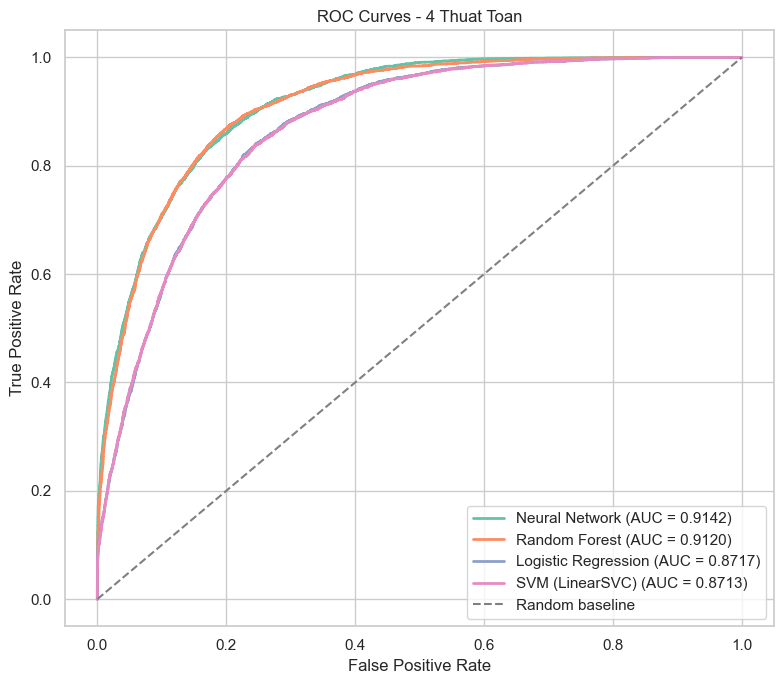

In [8]:
plt.figure(figsize=(8, 7))
for name, (fpr, tpr, auc) in sorted(roc_data.items(), key=lambda x: -x[1][2]):
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - 4 Thuat Toan')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Bar Chart So Sanh Metrics

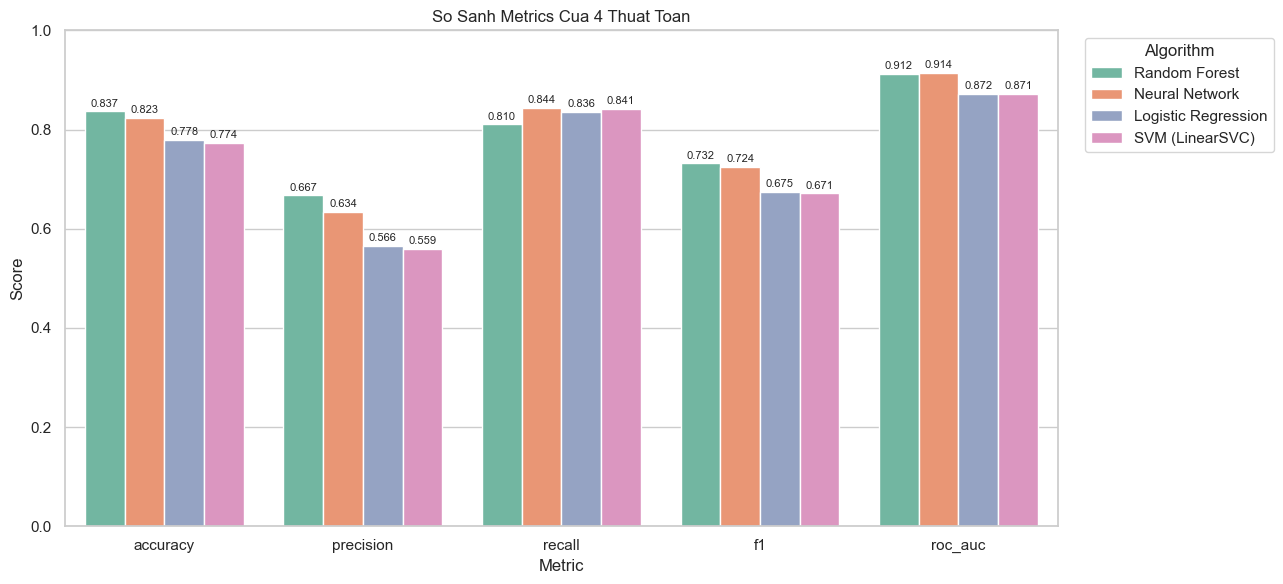

In [9]:
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
melted = comparison_df.melt(id_vars='model', value_vars=metrics_to_plot, var_name='metric', value_name='value')

plt.figure(figsize=(13, 6))
ax = sns.barplot(data=melted, x='metric', y='value', hue='model')
plt.title('So Sanh Metrics Cua 4 Thuat Toan')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.xlabel('Metric')
plt.legend(title='Algorithm', bbox_to_anchor=(1.02, 1), loc='upper left')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

## 8. Confusion Matrix Cua Tung Model

So sanh truc tiep TP/FP/FN/TN.

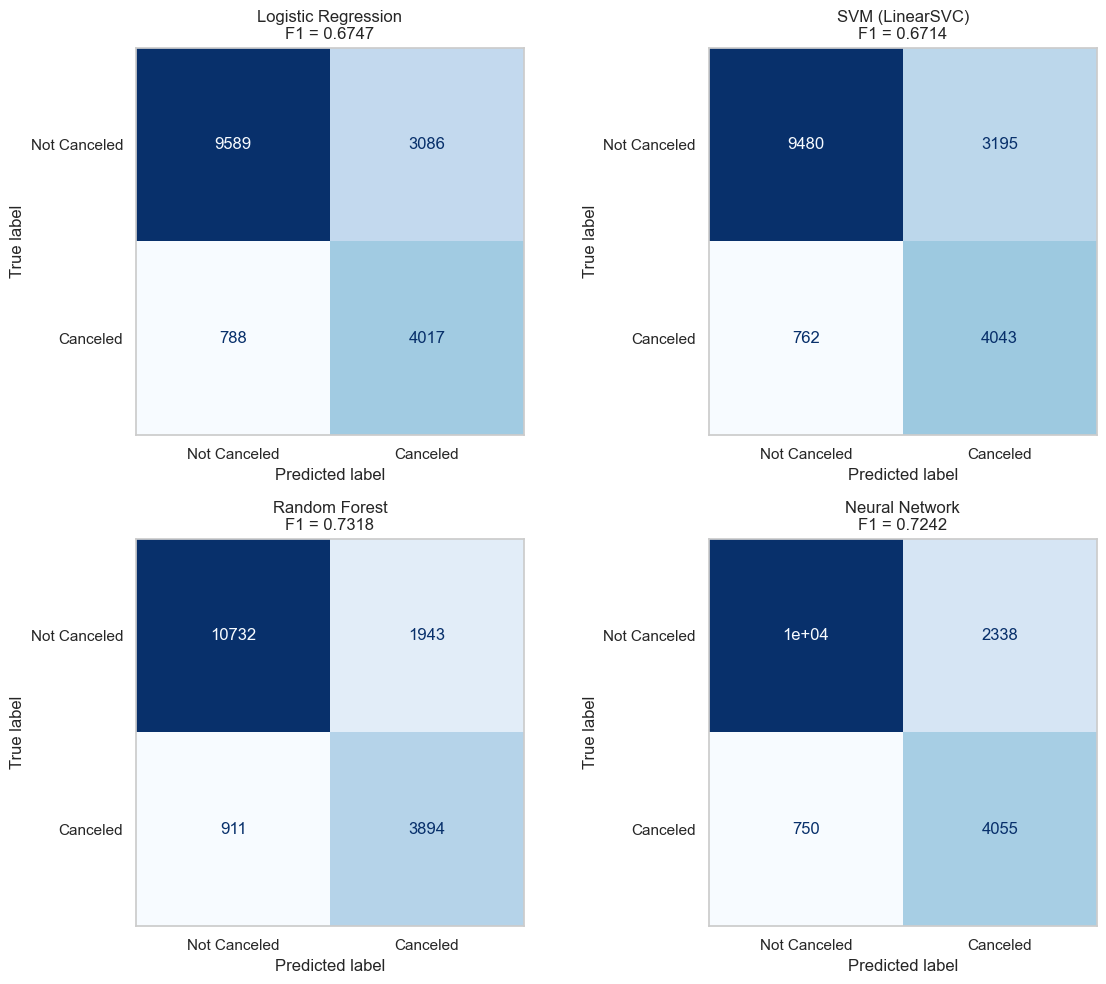

In [10]:
n_models = len(models)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Canceled', 'Canceled'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nF1 = {f1_score(y_test, y_pred):.4f}')
    axes[i].grid(False)

# Hide unused subplots if fewer than 4 models
for j in range(len(preds), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 9. Train-Test Gap Doi Chieu

Lay overfitting gap tu tung folder model de so sanh on dinh.

In [11]:
gap_paths = {
    'Logistic Regression': 'model/logistic_regression/logistic_regression_fe_outlier_overfitting_gap.csv',
    'SVM (LinearSVC)': 'model/svm/svm_overfitting_gap.csv',
    'Random Forest': 'model/random_forest/random_forest_overfitting_gap.csv',
    'Neural Network': 'model/neural_network/neural_network_overfitting_gap.csv',
}

gap_rows = []
for name, path in gap_paths.items():
    p = Path(path)
    if not p.exists():
        print(f'[!] MISSING: {path}')
        continue
    g = pd.read_csv(p)
    # The gap CSVs have one row with model_group + columns ending in _gap_train_minus_test
    row = g.iloc[0].to_dict()
    gap_rows.append({
        'model': name,
        'f1_gap': row.get('f1_gap_train_minus_test', np.nan),
        'roc_auc_gap': row.get('roc_auc_gap_train_minus_test', np.nan),
        'accuracy_gap': row.get('accuracy_gap_train_minus_test', np.nan),
    })

gap_df = pd.DataFrame(gap_rows).set_index('model')
gap_df.round(4)

,f1_gap,roc_auc_gap,accuracy_gap
model,,,
Logistic Regression,0.0029,0.0023,0.0023
SVM (LinearSVC),0.0039,0.0026,0.0033
Random Forest,0.0818,0.0487,0.0493
Neural Network,0.0351,0.0211,0.0238


In [12]:
# Ghep performance + gap thanh 1 bang summary
summary = comparison_df.set_index('model').join(gap_df, how='left')
summary = summary[['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'f1_gap', 'roc_auc_gap']]
summary_path = ARTIFACT_DIR / 'all_algorithms_summary.csv'
summary.to_csv(summary_path)
print('Saved:', summary_path)
summary.round(4)

Saved: model\all_algorithms_summary.csv


,accuracy,precision,recall,f1,roc_auc,f1_gap,roc_auc_gap
model,,,,,,,
Random Forest,0.8367,0.6671,0.8104,0.7318,0.9120,0.0818,0.0487
Neural Network,0.8233,0.6343,0.8439,0.7242,0.9142,0.0351,0.0211
Logistic Regression,0.7784,0.5655,0.8360,0.6747,0.8717,0.0029,0.0023
SVM (LinearSVC),0.7736,0.5586,0.8414,0.6714,0.8713,0.0039,0.0026


## 10. Ket Luan Va Chon Model Deploy

### Bang xep hang cuoi cung

| Hang | Thuat toan | F1 | ROC-AUC | F1 Gap | Diem manh chinh |
|---|---|---|---|---|---|
| 1 | **Random Forest** | 0.7318 | 0.9120 | 0.082 | F1 cao nhat, co feature_importance |
| 2 | **Neural Network** | 0.7242 | **0.9142** | 0.035 | ROC-AUC cao nhat, gap thap |
| 3 | Logistic Regression | 0.6747 | 0.8717 | 0.003 | Interpretable, gap rat nho |
| 4 | SVM (LinearSVC) | 0.6714 | 0.8713 | 0.004 | Gan trung LR, khong them gia tri |

### Recommendation cho frontend

**Lua chon chinh: Random Forest hoac Neural Network** (co the cho user chon hoac chay ca 2 song song).

- **Neu uu tien F1 + interpretability**: chon **Random Forest**. Co the hien thi top feature_importance trong UI de giai thich "vi sao booking nay co kha nang huy cao".
- **Neu uu tien ROC-AUC + on dinh**: chon **Neural Network**. Phu hop neu frontend muon sort danh sach booking theo xac suat huy giam dan.
- **LR/SVM**: chi nen dung lam baseline trong bao cao, khong nen lam model deploy chinh vi F1 thap hon RF/NN ~5 pp.

### Luu y ket noi frontend

1. **Cac model deu yeu cau input duoc apply feature engineering**: frontend can compute 8 feature engineered (`total_nights`, `total_guests`, `has_children`, `is_family`, `room_changed`, `has_agent`, `has_previous_cancellation`, `arrival_month_number`) truoc khi gui vao model.
2. **SVM khong co `predict_proba`** -> neu UI hien xac suat %, can boc `CalibratedClassifierCV` hoac loai SVM khoi UI.
3. **Preprocessing da bundled trong joblib**: chi can `joblib.load(...)` + `model.predict(df)` la xong, khong can fit lai encoder/scaler.
4. **Categorical handle_unknown='ignore'**: input la category moi se silently bi zero-vector. Backend nen validate truoc.